# Meta-Atom Library Optimization — Focusing with Interpolated Unit Cells

This notebook is the **fabrication-constrained child notebook** in the lens-design family. It builds
on [lens_optimization.ipynb](lens_optimization.ipynb): the optical goal is still to focus a plane
wave, but the trainable surface is now restricted to a **meta-atom library** rather than an arbitrary
phase mask.

## Assumes you know

- the focusing setup from [lens_optimization.ipynb](lens_optimization.ipynb),
- why a hyperbolic phase profile is the natural focusing reference, and
- the basics of optimizing a differentiable optical module.

## What changes relative to the parent notebook

- each pixel is parameterized by a bounded geometry variable instead of a free phase,
- optical transmission comes from interpolating a precomputed meta-atom lookup table, and
- the design is limited to what the unit-cell library can physically realize.

The parent notebook covers the focusing intuition; this notebook focuses on what changes when
fabrication constraints are part of the model.


## 0  Imports

The imports look similar to the parent lens notebook, but the core new dependency is the meta-atom
library interface in `fouriax`, used to turn geometry parameters into complex transmission values.


In [1]:
from __future__ import annotations

import argparse
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

import fouriax as fx

import os
from pathlib import Path as _Path
%matplotlib inline

REPO_ROOT = fx.utils.find_repo_root(_Path.cwd())
if _Path.cwd() != REPO_ROOT:
    os.chdir(REPO_ROOT)


EXAMPLES_ROOT = Path(__file__).resolve().parents[1]
EXAMPLES_DATA_DIR = EXAMPLES_ROOT / "data"
EXAMPLES_ARTIFACTS_DIR = EXAMPLES_ROOT / "artifacts"


## 1  Paths and Parameters

Besides the usual artifact path and optimization settings, this notebook introduces the NPZ lookup-table path and the selected wavelength used to slice the library. Those settings determine which
physical library and operating point the optimizer is allowed to use.


In [2]:
NPZ_PATH = Path(str(EXAMPLES_DATA_DIR / 'meta_atoms' / 'square_pillar_0p7um_cell_sweep_results.npz'))
ARTIFACTS_DIR = Path(str(EXAMPLES_ARTIFACTS_DIR))
PLOT_PATH = ARTIFACTS_DIR / "metaatom_opt_overview.png"
SUMMARY_PATH = ARTIFACTS_DIR / "metaatom_opt_summary.json"

SPEED_OF_LIGHT_M_PER_S = 299792458.0
SEED = 0
GRID_N = 64
GRID_DX_UM = 0.7
SELECTED_WAVELENGTH_UM = 1.3
DISTANCE_UM = 100.0
LR = 0.1
STEPS = 180
PLOT = True


## 2  Helper Functions

The helper loads the square-pillar sweep data, sorts the wavelength and geometry axes, and converts
transmission magnitude and phase into a complex meta-atom library. This is the interface between an
external electromagnetic sweep and the differentiable optical model used here.


In [3]:
def load_square_pillar_library(npz_path: Path) -> fx.MetaAtomLibrary:
    """Load LUT from NPZ keys: freqs [Hz], side_lengths [m], trans, phase."""
    with np.load(npz_path) as data:
        freqs_hz = np.asarray(data["freqs"], dtype=np.float64).reshape(-1)
        side_lengths_m = np.asarray(data["side_lengths"], dtype=np.float64).reshape(-1)
        trans = np.asarray(data["trans"], dtype=np.float64)
        phase = np.asarray(data["phase"], dtype=np.float64)

    wavelengths_um = (SPEED_OF_LIGHT_M_PER_S / freqs_hz) * 1e6
    side_lengths_um = side_lengths_m * 1e6

    wav_order = np.argsort(wavelengths_um)
    side_order = np.argsort(side_lengths_um)

    wavelengths_um = wavelengths_um[wav_order]
    side_lengths_um = side_lengths_um[side_order]

    trans = trans[side_order, :][:, wav_order]
    phase = phase[side_order, :][:, wav_order]

    transmission_complex = trans.T * np.exp(1j * phase.T)

    return fx.MetaAtomLibrary.from_complex(
        wavelengths_um=jnp.asarray(wavelengths_um, dtype=jnp.float32),
        parameter_axes=(jnp.asarray(side_lengths_um, dtype=jnp.float32),),
        transmission_complex=jnp.asarray(transmission_complex),
    )


## 3  Setup

We choose the library wavelength closest to the requested operating wavelength, construct the working
grid, and build an optical module whose first layer is `MetaAtomInterpolationLayer`.

Unlike the parent notebook, the trainable parameter is now a geometry map bounded between the minimum
and maximum side lengths present in the library. The propagation target is still the central focal
spot.


In [4]:
library = load_square_pillar_library(NPZ_PATH)

nearest_idx = int(jnp.argmin(jnp.abs(library.wavelengths_um - SELECTED_WAVELENGTH_UM)))
wavelength_um = float(library.wavelengths_um[nearest_idx])
grid = fx.Grid.from_extent(nx=GRID_N, ny=GRID_N, dx_um=GRID_DX_UM, dy_um=GRID_DX_UM)
spectrum = fx.Spectrum.from_scalar(wavelength_um)
field_in = fx.Field.plane_wave(grid=grid, spectrum=spectrum)

target_xy = (grid.nx // 2, grid.ny // 2)
propagator = fx.plan_propagation(
    mode="auto",
    grid=grid,
    spectrum=spectrum,
    distance_um=DISTANCE_UM,
)

side_axis = library.parameter_axes[0]
min_bounds = jnp.array([side_axis[0]], dtype=jnp.float32)
max_bounds = jnp.array([side_axis[-1]], dtype=jnp.float32)

def build_module(raw_params: jnp.ndarray) -> fx.OpticalModule:
    return fx.OpticalModule(
        layers=(
            fx.MetaAtomInterpolationLayer(
                library=library,
                raw_geometry_params=raw_params,
                min_geometry_params=min_bounds,
                max_geometry_params=max_bounds,
            ),
            propagator,
        )
    )


## 4  Loss Function and Optimization

The loss is deliberately minimal: maximize the on-axis focal intensity by minimizing its negative.
The optimizer therefore searches over physically realizable unit-cell geometries rather than over a
free phase profile.

This makes the comparison to the parent notebook meaningful: the optical task is the same, but the
design space is much narrower and more realistic.


In [5]:
def loss_fn(raw_params: jnp.ndarray) -> jnp.ndarray:
    module = build_module(raw_params)
    intensity = module.forward(field_in).intensity()
    center = intensity[0, target_xy[1], target_xy[0]]
    return -center

key = jax.random.PRNGKey(SEED)
raw_params = 0.1 * jax.random.normal(key, (grid.ny, grid.nx), dtype=jnp.float32)
optimizer = optax.adam(learning_rate=LR)

result = fx.optim.optimize_optical_module(
    init_params=raw_params,
    build_module=build_module,
    loss_fn=loss_fn,
    optimizer=optimizer,
    steps=STEPS,
    log_every=30,
)


step=000 loss=-0.516717


step=030 loss=-75.374443


step=060 loss=-83.535858


step=090 loss=-85.613884


step=120 loss=-87.197876


step=150 loss=-87.478600


step=179 loss=-87.633789


## 5  Evaluation

We evaluate the best library-constrained design against the same hyperbolic-phase reference used in
[lens_optimization.ipynb](lens_optimization.ipynb). In addition to the focal intensity profile, we can
now inspect the optimized **side-length map**, which is the actual fabrication-facing output of the
optimization.


In [6]:
final_intensity = np.asarray(result.best_module.forward(field_in).intensity())
optimized_profile = final_intensity[0, target_xy[1], :]

# Reference: phase profile for ideal spherical wavefront convergence at distance_um.
x_um, y_um = grid.spatial_grid()
k = 2.0 * jnp.pi / wavelength_um
hyperbolic_phase = -k * (jnp.sqrt(x_um * x_um + y_um * y_um + DISTANCE_UM**2) - DISTANCE_UM)
reference_module = fx.OpticalModule(
    layers=(
        fx.PhaseMask(phase_map_rad=hyperbolic_phase[None, :, :]),
        propagator,
    )
)

reference_intensity = np.asarray(reference_module.forward(field_in).intensity())
reference_profile = reference_intensity[0, target_xy[1], :]

final_layer = fx.MetaAtomInterpolationLayer(
    library=library,
    raw_geometry_params=result.best_params,
    min_geometry_params=min_bounds,
    max_geometry_params=max_bounds,
)
optimized_side_map = np.asarray(final_layer.bounded_geometry_params()[0])


## 6  Plot Results

The figure shows whether the constrained design still focuses well, what geometry map the optimizer
settled on, and how its focal profile compares with the ideal phase-only reference.

Interpret the result as a tradeoff plot: if the focus remains sharp while the geometry map stays
inside the library bounds, the meta-atom parameterization is expressive enough for this task.


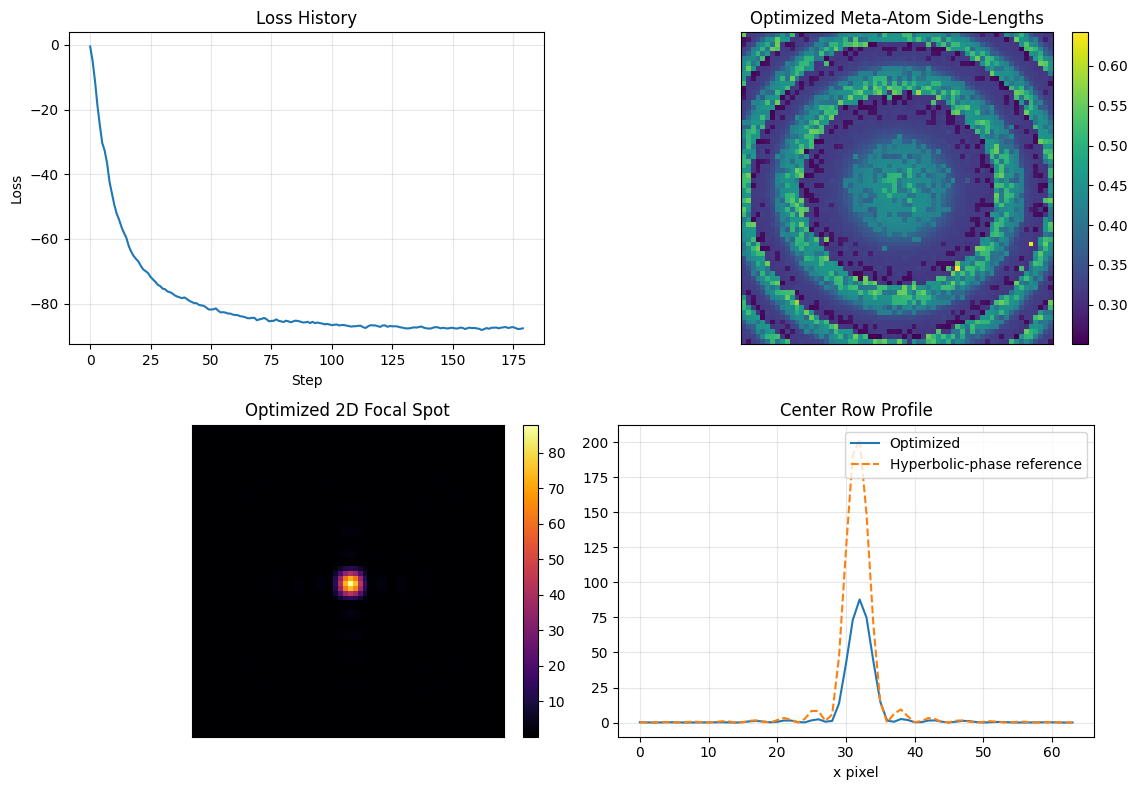

saved: artifacts/metaatom_opt_overview.png


In [7]:
if PLOT:
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0))

    axes[0, 0].plot(result.history)
    axes[0, 0].set_title("Loss History")
    axes[0, 0].set_xlabel("Step")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].grid(alpha=0.3)

    side_im = axes[0, 1].imshow(optimized_side_map, cmap="viridis")
    axes[0, 1].set_title("Optimized Meta-Atom Side-Lengths")
    axes[0, 1].set_xticks([])
    axes[0, 1].set_yticks([])
    plt.colorbar(side_im, ax=axes[0, 1], fraction=0.046, pad=0.04)

    focus_im = axes[1, 0].imshow(final_intensity[0], cmap="inferno")
    axes[1, 0].set_title("Optimized 2D Focal Spot")
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])
    plt.colorbar(focus_im, ax=axes[1, 0], fraction=0.046, pad=0.04)

    axes[1, 1].plot(optimized_profile, label="Optimized")
    axes[1, 1].plot(reference_profile, label="Hyperbolic-phase reference", linestyle="--")
    axes[1, 1].set_title("Center Row Profile")
    axes[1, 1].set_xlabel("x pixel")
    axes[1, 1].grid(alpha=0.3)
    axes[1, 1].legend()

    fig.tight_layout()
    fig.savefig(PLOT_PATH, dpi=150)
    plt.show()
    print(f"saved: {PLOT_PATH}")
